# **Ejemplo 3:**

Importando librerías correspondientes y configuramos el entorno:

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

np.random.seed(0)
torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| dispositivo:', device)

PyTorch 2.11.0+cpu | dispositivo: cpu


## **1. Generación de datos de referencia:**

A partir de la solución proporcionada por el método de diferencias finitas (método clásico), obtenemos los puntos para realizar la reconstrucción correspondiente del PINN junto con los coeficientes (definiendo $T= 1$ y $L = 5$):

campo generado: (101, 256) | max|u| = 1.0


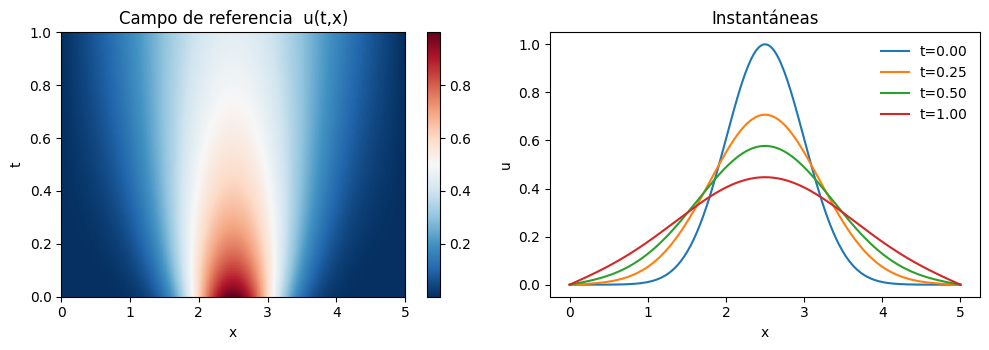

In [20]:
# Parámetros del problema
kappa_true = 0.5      # coeficiente de difusión (λ en tu notación)
L = 5.0               # longitud del dominio [0, L]

# Discretización espacial
Nx = 256
x_grid = np.linspace(0, L, Nx)  # dominio [0, L] con condiciones Dirichlet
dx = x_grid[1] - x_grid[0]

# Condiciones de borde (ejemplo)
def g1(t):  # condición en x=0
  return 0.0

def g2(t):  # condición en x=L
  return 0.0

# Función que implementa el lado derecho de la ecuación del calor
def diffusion_eq(t, u):
  u_internal = u.copy()

  # Aplicar condiciones de borde
  u_internal[0] = g1(t)    # borde izquierdo
  u_internal[-1] = g2(t)   # borde derecho

  # Segunda derivada con diferencias finitas (interior del dominio)
  uxx = np.zeros_like(u_internal)

  # Diferencias centradas para puntos internos (i=1..Nx-2)
  uxx[1:-1] = (u_internal[2:] - 2*u_internal[1:-1] + u_internal[:-2]) / dx**2

  #Fijando derivadas externas a 0 ya que no se usan en la evolución interna
  uxx[0] = 0
  uxx[-1] = 0
  return kappa_true * uxx

def gaussian_initial(x, mu=L/2, sigma=0.5):
  """Condición inicial tipo campana de Gauss"""
  return np.exp(-(x - mu)**2 / (2*sigma**2))

# Condición inicial Gaussiana
u0 = gaussian_initial(x_grid)

T = 1.0
t_grid = np.linspace(0, T, 101)
sol = solve_ivp(diffusion_eq, [0, T], u0, t_eval=t_grid,
                method='RK45', rtol=1e-7, atol=1e-9, max_step=0.005)
U = sol.y.T                                # campo de referencia, forma (nt, nx)
print('campo generado:', U.shape, '| max|u| =', round(float(np.abs(U).max()), 3))

#Gráficas:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
im = a1.imshow(U, aspect='auto', origin='lower', extent=[x_grid.min(), x_grid.max(), 0, T], cmap='RdBu_r')
a1.set_xlabel('x'); a1.set_ylabel('t'); a1.set_title('Campo de referencia  u(t,x)')
fig.colorbar(im, ax=a1)

for k in [0, 25, 50, 100]:
    a2.plot(x_grid, U[k], label=f't={t_grid[k]:.2f}')
a2.set_xlabel('x'); a2.set_ylabel('u'); a2.set_title('Instantáneas'); a2.legend(frameon=False)
plt.tight_layout(); plt.show()

## **2. Seleccionando cierta cantidad de puntos para hallar el valor de $κ$:**

Tomamos un subconjunto **aleatorio y disperso** de puntos $(t,x,u)$ y les añadimos ruido gaussiano. Estas son las &uacute;nicas "mediciones" que ver&aacute; el PINN.


### **Con datos limpios:**

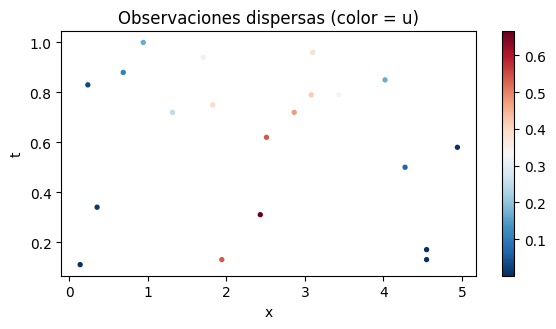

In [22]:
#Obteniendo datos limpios
N_obs   = 20          # numero de observaciones dispersas

# Crear malla completa de puntos espacio-temporales
TT, XX = np.meshgrid(t_grid, x_grid, indexing='ij')
t_flat = TT.ravel()   # vector de tiempos (nt*nx,)
x_flat = XX.ravel()   # vector de posiciones (nt*nx,)
u_flat = U.ravel()    # vector de valores de u (nt*nx,)

# Seleccionar N_obs puntos aleatorios sin reemplazo
idx_clean = np.random.choice(t_flat.size, N_obs, replace=False)
t_obs_clean = t_flat[idx_clean]
x_obs_clean = x_flat[idx_clean]
u_obs_clean = u_flat[idx_clean]

plt.figure(figsize=(6, 3.4))
plt.scatter(x_obs_clean, t_obs_clean, c=u_obs_clean, s=8, cmap='RdBu_r')
plt.xlabel('x'); plt.ylabel('t'); plt.title('Observaciones dispersas (color = u)')
plt.colorbar(); plt.tight_layout(); plt.show()

### **Datos con ruido gaussiano:**

20 observaciones ruidosas (ruido sigma=0.01)


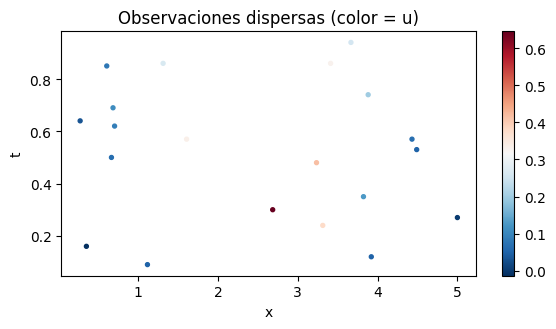

In [ ]:
#Reproducción de datos con 1% de ruido:
N_obs   = 20          # numero de observaciones dispersas
noise   = 0.01        # nivel de ruido

# Crear malla completa de puntos espacio-temporales
TT, XX = np.meshgrid(t_grid, x_grid, indexing='ij')
t_flat = TT.ravel()   # vector de tiempos (nt*nx,)
x_flat = XX.ravel()   # vector de posiciones (nt*nx,)
u_flat = U.ravel()    # vector de valores de u (nt*nx,)

# Seleccionar N_obs puntos aleatorios sin reemplazo
idx = np.random.choice(t_flat.size, N_obs, replace=False)
t_obs = t_flat[idx]
x_obs = x_flat[idx]
u_obs = u_flat[idx] + noise * np.random.randn(N_obs)   # añadir ruido gaussianO

print(f'{N_obs} observaciones ruidosas (ruido sigma={noise})')

plt.figure(figsize=(6, 3.4))
plt.scatter(x_obs, t_obs, c=u_obs, s=8, cmap='RdBu_r')
plt.xlabel('x'); plt.ylabel('t'); plt.title('Observaciones dispersas (color = u)')
plt.colorbar(); plt.tight_layout(); plt.show()

## **3. Construcción del PINN inverso**

La red toma $(t,x)$ y devuelve $\tilde u$. Las derivadas $u_t, u_x, u_{xx}$ del residuo se obtienen por diferenciaci&oacute;n autom&aacute;tica. El coeficiente $\kappa$ se declara como par&aacute;metro entrenable (inicializado en $0$) y entra al optimizador junto con los pesos de la red.

### **Declaración de la red neuronal:**

In [ ]:
class MLP(nn.Module):
    def __init__(self, layers=(2, 40, 40, 40, 1)):
        super().__init__()
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(nn.Tanh())
        self.net = nn.Sequential(*mods)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, t, x):
        return self.net(torch.cat([t, x], dim=1))


### **PINN con κ entrenable:**

Se entrena la red (de manera similar al ejemplo proporcionado de Burgers):

#### **A partir de los datos limpios:**

In [25]:
#Función para convertir a tensor:
def to_col(a):
    return torch.tensor(a, dtype=torch.float32, device=device).reshape(-1, 1)

#Datos de observacion:
t_d = to_col(t_obs_clean)
x_d = to_col(x_obs_clean)
u_d = to_col(u_obs_clean)

#Puntos de colocacion para el residuo (con gradiente)
N_f = 4000
tf = np.random.uniform(0, T, N_f); xf = np.random.uniform(0, L, N_f)
t_f = to_col(tf).requires_grad_(True); x_f = to_col(xf).requires_grad_(True)

net = MLP().to(device)
kappa_clean = nn.Parameter(torch.tensor(0.0, device=device))
opt  = torch.optim.Adam(list(net.parameters()) + [kappa_clean], lr=1e-3)

def residual(t, x):
    u   = net(t, x)
    u_t = torch.autograd.grad(u,   t, torch.ones_like(u),   create_graph=True)[0]
    u_x = torch.autograd.grad(u,   x, torch.ones_like(u),   create_graph=True)[0]
    u_xx= torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t - kappa_clean * u_xx

#Entrenamiento:
n_steps = 12000
hist_clean = {'kappa_clean': []}
t0 = time.perf_counter()
for it in range(n_steps + 1):
    opt.zero_grad()
    loss_data = ((net(t_d, x_d) - u_d)**2).mean()
    loss_phys = (residual(t_f, x_f)**2).mean()
    loss = loss_data + loss_phys
    loss.backward(); opt.step()
    hist_clean['kappa_clean'].append(kappa_clean.item())
    if it % 3000 == 0:
        print(f'  paso {it:5d}  L={loss.item():.3e}  '
              f'kappa_clean={kappa_clean.item():.4f}')
train_time = time.perf_counter() - t0

print(f'Tiempo de entrenamiento entrenamiento: {train_time:.1f} s')

  paso     0  L=2.147e+00  kappa_clean=-0.0010
  paso  3000  L=6.005e-04  kappa_clean=0.2167
  paso  6000  L=1.853e-04  kappa_clean=0.3456
  paso  9000  L=1.146e-04  kappa_clean=0.3826
  paso 12000  L=5.923e-05  kappa_clean=0.4109
Tiempo de entrenamiento entrenamiento: 227.0 s


#### **A partir de los datos con ruido:**

In [24]:
#Función para convertir a tensor:
def to_col(a):
    return torch.tensor(a, dtype=torch.float32, device=device).reshape(-1, 1)

#Datos de observacion:
t_d = to_col(t_obs)
x_d = to_col(x_obs)
u_d = to_col(u_obs)

#Puntos de colocacion para el residuo (con gradiente)
N_f = 4000
tf = np.random.uniform(0, T, N_f); xf = np.random.uniform(0, L, N_f)  # Cambiado: dominio [0, L]
t_f = to_col(tf).requires_grad_(True); x_f = to_col(xf).requires_grad_(True)

net = MLP().to(device)
kappa = nn.Parameter(torch.tensor(0.0, device=device))
opt  = torch.optim.Adam(list(net.parameters()) + [kappa], lr=1e-3)

def residual(t, x):
    u   = net(t, x)
    u_t = torch.autograd.grad(u,   t, torch.ones_like(u),   create_graph=True)[0]
    u_x = torch.autograd.grad(u,   x, torch.ones_like(u),   create_graph=True)[0]
    u_xx= torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t - kappa * u_xx

#Entrenamiento:
n_steps = 12000
hist = {'kappa': []}
t0 = time.perf_counter()
for it in range(n_steps + 1):
    opt.zero_grad()
    loss_data = ((net(t_d, x_d) - u_d)**2).mean()
    loss_phys = (residual(t_f, x_f)**2).mean()
    loss = loss_data + loss_phys
    loss.backward(); opt.step()
    hist['kappa'].append(kappa.item())
    if it % 3000 == 0:
        print(f'  paso {it:5d}  L={loss.item():.3e}  '
              f'kappa={kappa.item():.4f}')
train_time = time.perf_counter() - t0

print(f'Tiempo de entrenamiento entrenamiento: {train_time:.1f} s')

  paso     0  L=7.016e-02  kappa=-0.0010
  paso  3000  L=1.824e-04  kappa=0.3652
  paso  6000  L=6.856e-05  kappa=0.4308
  paso  9000  L=3.443e-05  kappa=0.4574
  paso 12000  L=4.504e-05  kappa=0.4665
Tiempo de entrenamiento entrenamiento: 226.6 s


## **3. Coeficiente recuperado**

Comparación del coeficiente recuperado ante el real.

### **A partir de los datos limpios:**

coeficiente      verdadero    recuperado     error
----------------------------------------------------
kappa               0.5000        0.4109    17.82%
error L2 relativo del campo reconstruido: 6.069e-02


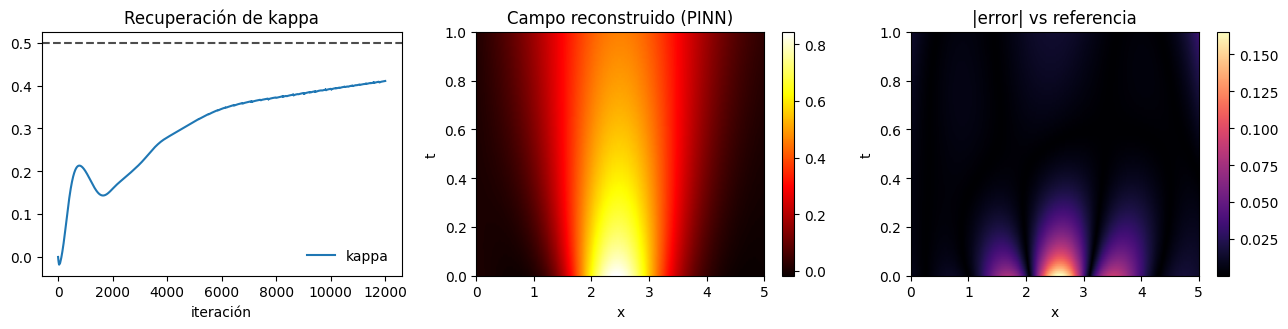

In [26]:
err_cl = 100 * abs(kappa_clean.item() - kappa_true) / kappa_true  # Nota: kappa_real es el valor verdadero
print('='*52)
print(f'{"coeficiente":<14}{"verdadero":>12}{"recuperado":>14}{"error":>10}')
print('-'*52)
print(f'{"kappa":<14}{kappa_true:>12.4f}{kappa_clean.item():>14.4f}{err_cl:>9.2f}%')
print('='*52)

#Campo reconstruido por el PINN sobre toda la malla
with torch.no_grad():
    u_rec = net(to_col(TT.ravel()), to_col(XX.ravel())).cpu().numpy().reshape(U.shape)
relL2_field = np.sqrt(np.mean((u_rec - U)**2)) / np.sqrt(np.mean(U**2))
print(f'error L2 relativo del campo reconstruido: {relL2_field:.3e}')

fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
axs[0].plot(hist_clean['kappa_clean'], label='kappa')
axs[0].axhline(kappa_true, color='0.3', ls='--')
axs[0].set_xlabel('iteración'); axs[0].set_title('Recuperación de kappa'); axs[0].legend(frameon=False)
im1 = axs[1].imshow(u_rec, aspect='auto', origin='lower',
                    extent=[0, L, 0, T], cmap='hot')
axs[1].set_title('Campo reconstruido (PINN)')
axs[1].set_xlabel('x'); axs[1].set_ylabel('t'); fig.colorbar(im1, ax=axs[1])
im2 = axs[2].imshow(np.abs(u_rec - U), aspect='auto', origin='lower',
                    extent=[0, L, 0, T], cmap='magma')
axs[2].set_title('|error| vs referencia')
axs[2].set_xlabel('x'); axs[2].set_ylabel('t'); fig.colorbar(im2, ax=axs[2])
plt.tight_layout(); plt.show()

### **A partir de los datos con ruido:**



coeficiente      verdadero    recuperado     error
----------------------------------------------------
kappa               0.5000        0.4665     6.69%
error L2 relativo del campo reconstruido: 6.069e-02


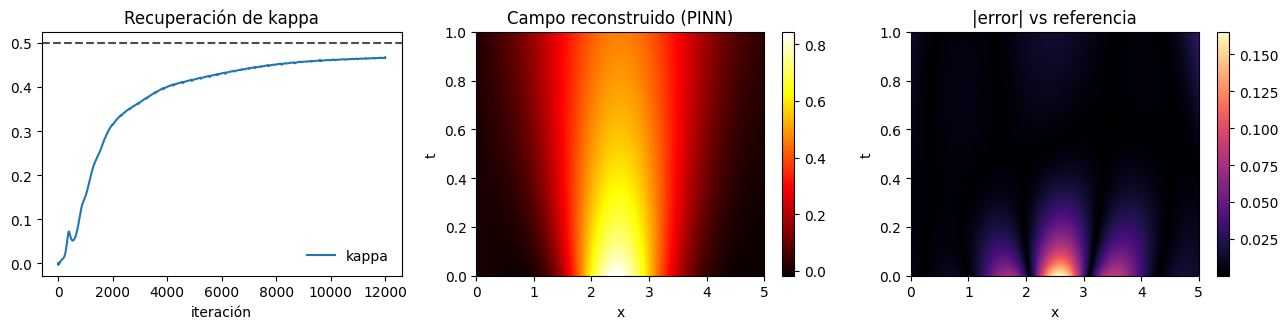

In [27]:
err = 100 * abs(kappa.item() - kappa_true) / kappa_true  # Nota: kappa_real es el valor verdadero
print('='*52)
print(f'{"coeficiente":<14}{"verdadero":>12}{"recuperado":>14}{"error":>10}')
print('-'*52)
print(f'{"kappa":<14}{kappa_true:>12.4f}{kappa.item():>14.4f}{err:>9.2f}%')
print('='*52)

#Campo reconstruido por el PINN sobre toda la malla
with torch.no_grad():
    u_rec = net(to_col(TT.ravel()), to_col(XX.ravel())).cpu().numpy().reshape(U.shape)
relL2_field = np.sqrt(np.mean((u_rec - U)**2)) / np.sqrt(np.mean(U**2))
print(f'error L2 relativo del campo reconstruido: {relL2_field:.3e}')

fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
axs[0].plot(hist['kappa'], label='kappa')
axs[0].axhline(kappa_true, color='0.3', ls='--')
axs[0].set_xlabel('iteración'); axs[0].set_title('Recuperación de kappa'); axs[0].legend(frameon=False)
im1 = axs[1].imshow(u_rec, aspect='auto', origin='lower',
                    extent=[0, L, 0, T], cmap='hot')
axs[1].set_title('Campo reconstruido (PINN)')
axs[1].set_xlabel('x'); axs[1].set_ylabel('t'); fig.colorbar(im1, ax=axs[1])
im2 = axs[2].imshow(np.abs(u_rec - U), aspect='auto', origin='lower',
                    extent=[0, L, 0, T], cmap='magma')
axs[2].set_title('|error| vs referencia')
axs[2].set_xlabel('x'); axs[2].set_ylabel('t'); fig.colorbar(im2, ax=axs[2])
plt.tight_layout(); plt.show()